# Task 1: Confirm the Memorization Regime

**Goal:** Sweep over small values of `n_train` and confirm that the GMM score model is in a clear
memorization regime. We look at `mean_ratio(k)` — the ratio of (error to nearest training neighbor)
/ (error to a random training sample) — at each wavenumber ring. Values well below 1 mean the
generated samples are much closer to their nearest neighbor than to a random training sample, i.e.,
they are memorized.

This notebook is self-contained and does NOT implement Task 2 (per-wavenumber memorization fraction).
Its only job is to confirm that the setup produces clear memorization at low `n_train`.

---
**Decisions made here that affect downstream tasks — read before continuing:**

1. **Unbiased data only.** `add_fourier_bias_to_result()` is deliberately skipped. The bias injection
   was designed for a different experiment (studying training-data spectral bias). Here we want clean
   multiband Matérn fields so the spectral structure is known and uncontaminated.

2. **n_train sweep: [5, 10, 20, 32].** These are the sizes we test. 32 is the baseline from the
   existing script; 5 and 10 are very small and expected to memorize strongly; 20 is borderline.
   The right value to use in Task 2 is whichever gives a clean memorization signal at low-k
   while still being ambiguous at high-k — that's the interesting regime.

3. **n_generated = 32 (fixed across all runs).** More than the existing script's 16 to get slightly
   better statistics. Latents are fixed by seed so the starting points are identical across
   `n_train` values — this makes curves more directly comparable.

4. **NN matching is done in the coarse band** (same as the existing script). For each generated sample
   we find its nearest training neighbor in low-frequency space, then compute the ring-wise error
   relative to that neighbor at ALL frequencies. This is the right setup for Task 3 (cross-scale
   memorization analysis) because it directly asks: given low-k memorization, what happens at high-k?

5. **1000 SDE steps.** Same as the existing script. Fewer steps produce noisier samples and can
   artificially suppress memorization. Do not reduce this.

6. **Random baseline uses n_ref=64.** Each reference draw picks a random training sample (with
   replacement) for each generated sample and computes the ring-wise error. The ratio
   err_to_NN / mean(err_to_random) is the memorization signal.


In [ ]:
# All dependencies are inlined below — no local src/ files needed.
# Safe to run on Colab or any machine without the repo structure.

import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"device: {device}")


In [ ]:
# ── Inlined: multiband_data_utils.py + diffusion_score_models.py ─────────────
# These were originally in src/. Inlined here for Colab compatibility.

import math
import numpy as np
import torch
import torch.nn as nn
from scipy.stats import norm
from scipy import integrate

# ── multiband_data_utils ──────────────────────────────────────────────────────
import torch


def generate_matern_laplace(num_samples, grid_size, sigma_sq, length_scale, s, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    freq = torch.fft.fftfreq(grid_size) * grid_size
    freq_x, freq_y = torch.meshgrid(freq, freq, indexing="ij")
    laplacian = freq_x**2 + freq_y**2

    spectral_density = sigma_sq * (laplacian + (length_scale**2)) ** (-s)
    spectral_density[0, 0] = 0
    spectral_density = spectral_density.unsqueeze(0)

    noise_real = torch.randn(num_samples, grid_size, grid_size)
    noise_imag = torch.randn(num_samples, grid_size, grid_size)
    noise = noise_real + 1j * noise_imag

    spectral_sample = torch.sqrt(spectral_density) * noise
    sample = torch.fft.ifft2(spectral_sample, norm="forward").real
    return sample


def make_knrm_grid(grid_size: int, device=None):
    freq = torch.fft.fftfreq(grid_size, device=device) * grid_size
    kx, ky = torch.meshgrid(freq, freq, indexing="ij")
    return torch.sqrt(kx**2 + ky**2)


def make_radial_band_mask(grid_size: int, k_lo: float, k_hi: float, device=None, dtype=torch.float32):
    knrm = make_knrm_grid(grid_size, device=device)
    return ((knrm >= k_lo) & (knrm < k_hi)).to(dtype)


def radial_bandpass(x: torch.Tensor, mask: torch.Tensor, norm="forward"):
    X = torch.fft.fft2(x, dim=(-2, -1), norm=norm)
    Xf = X * mask
    return torch.fft.ifft2(Xf, dim=(-2, -1), norm=norm).real


@torch.no_grad()
def band_power_fraction(x: torch.Tensor, mask: torch.Tensor, norm=None, eps=1e-12):
    X = torch.fft.fft2(x, dim=(-2, -1), norm=norm)
    P = (X.real**2 + X.imag**2)

    P_in = (P * mask).sum(dim=(-2, -1))
    P_tot = P.sum(dim=(-2, -1)).clamp_min(eps)
    return P_in / P_tot


def generate_multiband_dataset_postmask(
    num_samples: int,
    grid_size: int,
    components: list[dict],
    weights: list[float] | None = None,
    seed: int | None = None,
    normalize: bool = True,
    device=None,
):
    device = device or "cpu"
    if weights is None:
        weights = [1.0] * len(components)
    if len(weights) != len(components):
        raise ValueError("weights and components must have same length")

    xs, ffts, used_bands = {}, {}, {}

    for j, comp in enumerate(components):
        name = comp.get("name", f"comp{j}")
        comp_seed = None if seed is None else seed + 10_000 * j

        xj = generate_matern_laplace(
            num_samples=num_samples,
            grid_size=grid_size,
            sigma_sq=comp.get("sigma_sq", 1.0),
            length_scale=comp.get("kappa", comp.get("length_scale", 1.0)),
            s=comp.get("s", 2.0),
            seed=comp_seed,
        ).to(device)

        band = comp.get("band", None)
        if band is not None:
            k_lo, k_hi = band
            mask = make_radial_band_mask(grid_size, k_lo, k_hi, device=device, dtype=xj.dtype)
            xj = radial_bandpass(xj, mask)
            used_bands[name] = band

        xs[name] = xj
        ffts[name] = torch.fft.fft2(xj, dim=(-2, -1))

    x = sum(w * xs[components[i].get("name", f"comp{i}")] for i, w in enumerate(weights))
    X = torch.fft.fft2(x, dim=(-2, -1))

    normalization = None
    if normalize:
        mean = x.mean()
        std = x.std().clamp_min(1e-8)
        x = (x - mean) / std
        normalization = {"mean": mean.item(), "std": std.item()}

    return {
        "combined": x,
        "components": xs,
        "component_ffts": ffts,
        "combined_fft": X,
        "bands": used_bands,
        "normalization": normalization,
        "grid_size": grid_size,
    }


def make_radial_k_grid(N, device=None):
    k = torch.fft.fftfreq(N, d=1.0, device=device) * N
    kx, ky = torch.meshgrid(k, k, indexing="ij")
    return torch.sqrt(kx**2 + ky**2)


def add_fourier_bias_to_result(
    result: dict,
    kmin: float = None,
    kmax: float = None,
    k0: float = None,
    width: float = None,
    strength: float = 0.10,
    seed: int = 123,
    overwrite_combined: bool = True,
) -> dict:
    out = dict(result)

    x = out["combined"]
    _, N, _ = x.shape
    device = x.device

    k = torch.fft.fftfreq(N, d=1.0, device=device) * N
    kx, ky = torch.meshgrid(k, k, indexing="ij")
    kr = torch.sqrt(kx**2 + ky**2)

    if k0 is not None and width is not None:
        mask = ((kr >= k0 - width / 2) & (kr <= k0 + width / 2)).float()
    elif kmin is not None and kmax is not None:
        mask = ((kr >= kmin) & (kr <= kmax)).float()
    else:
        raise ValueError("Provide (kmin, kmax) or (k0, width)")

    g = torch.Generator(device=device)
    g.manual_seed(seed)
    w = torch.randn(N, N, generator=g, device=device)
    W = torch.fft.fft2(w, norm="forward")
    W_f = W * mask
    p = torch.fft.ifft2(W_f, norm="forward").real
    p = p - p.mean()
    p = p / p.std().clamp_min(1e-8)

    x_biased = x + strength * p.unsqueeze(0)

    out["combined_clean"] = x
    out["combined_biased"] = x_biased
    out["combined_biased_fft"] = torch.fft.fft2(x_biased, dim=(-2, -1))
    out["bias_pattern"] = p
    out["bias_mask"] = mask
    out["bias_meta"] = {
        "kmin": kmin,
        "kmax": kmax,
        "k0": k0,
        "width": width,
        "strength": strength,
        "seed": seed,
    }

    if overwrite_combined:
        out["combined"] = x_biased

    return out


# ── diffusion_score_models ────────────────────────────────────────────────────
import torch
import matplotlib.pyplot as plt
from timeit import default_timer
import copy


import numpy as np
import torch.nn as nn
from scipy.stats import norm
from scipy import integrate

class DiffusionModel:
    """ Base class for diffusion models with score-based sampling.
        Sampler evolves dx/dt = f(x,t) - g(t) * s(x,t) + sqrt{g(t)} * N(0,1) from T to 0,
        given the forward process dx/dt = f(x,t) +  sqrt{g(t)} * N(0,1) from 0 to T.
    """

    def __init__(self):
        self.T     = 1.
        self.eps   = 1e-3

    def SDEsampler(self, score_net, latents, num_steps=100):
        batch_size = latents.shape[0]

        # define initial samples
        init_T = self.T * torch.ones(batch_size, device=latents.device)
        init_x = latents * self.marginal_prob_std(init_T)[:, None]
        x = init_x

        # define steps
        time_steps = torch.linspace(self.T, self.eps, num_steps)
        dt = time_steps[0] - time_steps[1]

        with torch.no_grad():
            for (j,time) in enumerate(time_steps):
                batch_time = torch.ones(batch_size, device=latents.device) * time
                # evaluate score function
                sx = score_net(x, batch_time)
                # evaluate update to x
                f = self.drift(x, batch_time)
                g = self.diffusion_coeff(batch_time)
                drift = -1.*f + (g**2)[:,None]*sx
                x = x + dt * drift + torch.sqrt(dt)*g[:,None]*torch.randn_like(x)

        return x

    def ODEsampler(self, score_net, latents, T0=None, T1=None, err_tol=1e-5):
        batch_size = latents.shape[0]

        # extract device
        device=latents.device
        
        # set initial and final times
        if T0 == None:
            T0 = self.T
        elif T1 == None:
            T1 = self.eps

        # define initial samples
        init_T = T0 * torch.ones(batch_size, device=latents.device)
        init_x = latents * self.marginal_prob_std(init_T)[:, None]

        def score_eval_wrapper(sample, time_steps):
            """A wrapper of the score-based model for use by the ODE solver."""
            sample = torch.tensor(sample, device=device, dtype=torch.float32).reshape(latents.shape)
            with torch.no_grad():
                score = score_net(sample, time_steps)
            return score
  
        def ode_func(t, x):        
            """The ODE function for use by the ODE solver."""
            batch_time = torch.ones(batch_size, device=latents.device) * t
            g = self.diffusion_coeff(batch_time)
            f = self.drift(x.reshape(latents.shape), batch_time)
            rhs = f - 0.5*(g**2)[:,None] * score_eval_wrapper(x, batch_time)
            return rhs.detach().numpy().reshape((-1,)).astype(np.float64)
  
        # Run the RK solver
        res = integrate.solve_ivp(ode_func, (T0, T1), init_x.reshape(-1).cpu().numpy(), \
                                  rtol=err_tol, atol=err_tol, method='RK45', dense_output=True)
        
        x_shape = [latents.shape[0], latents.shape[1], len(res.t)]
        x = torch.tensor(res.y, device=latents.device, dtype=torch.float32).reshape(x_shape)
        return (res.t, x)
     
    def ODEsampler_fixedstep(self, score_net, latents, num_steps=100):
        batch_size = latents.shape[0]

        # define initial samples
        init_T = self.T * torch.ones(batch_size, device=latents.device)
        init_x = latents * self.marginal_prob_std(init_T)[:, None]
        x = init_x

        # define steps
        time_steps = torch.linspace(self.T, self.eps, num_steps)
        dt = time_steps[0] - time_steps[1]

        with torch.no_grad():
            for (j,time) in enumerate(time_steps):
                batch_time = torch.ones(batch_size, device=latents.device) * time
                # evaluate score function
                sx = score_net(x, batch_time)
                # evaluate update to x
                f = self.drift(x, batch_time)
                g = self.diffusion_coeff(batch_time)
                drift = (-1.*f + 0.5*(g**2)[:,None]*sx)
                x = x + dt * drift
        
        return (time_steps, x)

class VP(DiffusionModel):
    def __init__(self):
        super().__init__()
        self.beta_min = 0.001
        self.beta_max = 3

    def beta_t(self, t):
        """ Compute beta(t) factor in linear drift f(x,t) = -0.5*beta(t)*x
        """
        return self.beta_min + t*(self.beta_max - self.beta_min)

    def alpha_t(self, t):
        """ Compute alpha(t)=\int_0^t \beta(s)ds for beta defined in linear drift
        """
        return t*self.beta_min + 0.5 * t**2 * (self.beta_max - self.beta_min)

    def drift(self, x, t):
        """
        x: location of J particles in N dimensions, shape (J, N)
        t: time (number)
        returns the drift of a time-changed OU-process for each batch member, shape (J, N)
        """
        return -0.5*self.beta_t(t[:,None])*x

    def marginal_prob_mean(self, t):
        """ Compute the mean factor of $p_{0:t}(x(t) | x(0))$.
        """
        return torch.exp(-0.5 * self.alpha_t(t))

    def marginal_prob_std(self, t):
        """ Compute the standard deviation of $p_{0:t}(x(t) | x(0))$.
        """
        return torch.sqrt(1 - torch.exp(-self.alpha_t(t)))

    def diffusion_coeff(self, t):
        """Compute the diffusion coefficient of our SDE g(t).
        """
        return torch.sqrt(self.beta_t(t))

class VE(DiffusionModel):
    def __init__(self):
        super().__init__()
        self.sigma = 10.

    def drift(self, x, t):
        return torch.zeros(x.shape)

    def marginal_prob_mean(self, t):
        """ Compute the mean factor of $p_{0:t}(x(t) | x(0))$.
        """
        return torch.ones((1,))

    def marginal_prob_std(self, t):
        """Compute the standard deviation of $p_{0:t}(x(t) | x(0))$.
           The variance is given by \int_0^t g(s) ds.
        """    
        return torch.sqrt((self.sigma**(2 * t) - 1.) / 2. / np.log(self.sigma))

    def diffusion_coeff(self, t):
        """Compute the diffusion coefficient of our SDE g(t).
        """
        return self.sigma**t

class GMM_score(nn.Module):
    '''
        GMM score function which corresponds to the stationary point of the denoising score-matching loss function
    '''
    def __init__(self, train_data, marginal_prob_mean, marginal_prob_std):
        super().__init__()
        self.register_buffer("train_data", train_data)
        self.marginal_prob_mean = marginal_prob_mean 
        self.marginal_prob_std  = marginal_prob_std

    def pdf_weights(self, x, t):
        # compute mean and sigma
        sigma = self.marginal_prob_std(t)
        meanf = self.marginal_prob_mean(t)
        # evaluate Gaussian densities
        logpdf_x_yi = torch.zeros((x.shape[0],self.train_data.shape[0]), device=x.device)
        for i in range(self.train_data.shape[0]):
            logpdf_x_yi[:,i] = self.log_normal_pdf(x, meanf[:,None] * self.train_data[i,:], sigma)
        # compute weighted average
        weights = torch.softmax(logpdf_x_yi, axis=1)
        return weights
        
    def forward(self, x, t):
        # compute weights
        weights = self.pdf_weights(x, t)
        # compute sigma
        sigma = self.marginal_prob_std(t)
        # compute weighted average
        evals = self.marginal_prob_mean(t)[:,None] * torch.mm(weights, self.train_data)
        evals[torch.isnan(evals)] = 0.0
        return (evals - x)/(sigma[:, None]**2)

    def log_normal_pdf(self, x, y, sigma):
        # ignoring normalization constant
        assert(x.shape[0] == len(sigma))
        return -0.5*torch.sum((x - y)**2,axis=1)/sigma**2

    def normal_pdf(self, x, y, sigma):
        return torch.exp(self.log_normal_pdf(x, y, sigma))

class GMM_score_TikhonovRegularized(GMM_score):
    '''
        GMM score function which corresponds to the stationary point of the regularized denoising
        score-matching loss function using Tikonov regularization with parameter const/sigma(t)^2
    '''
    def __init__(self, train_data, marginal_prob_mean, marginal_prob_std, diffusion_coeff, constant=1.0):
        super().__init__(train_data, marginal_prob_mean, marginal_prob_std)
        self.diffusion_coeff = diffusion_coeff
        self.register_buffer("constant", torch.tensor([constant]))
        
    def forward(self, x, t):
        # compute weights
        weights = self.pdf_weights(x, t)     
        # compute sigma and diffusion coefficient   
        sigma = self.marginal_prob_std(t)
        g = self.diffusion_coeff(t)
        # compute weighted average
        evals = self.marginal_prob_mean(t)[:,None] * torch.mm(weights, self.train_data)
        evals[torch.isnan(evals)] = 0.0
        return (evals - x)/(sigma[:, None]**2 + self.constant)

class GMM_score_EmpiricalBayes(GMM_score):
    '''
        GMM score function which corresponds to the stationary point of the regularized denoising
        score-matching loss function using Empirical Bayes regularization with parameter tau_const
    '''
    def __init__(self, train_data, marginal_prob_mean, marginal_prob_std, tau_constant=1.0):
        super().__init__(train_data, marginal_prob_mean, marginal_prob_std)
        self.tau_constant = tau_constant
        
    def pdf_weights(self, x, t):
        # compute mean and sigma
        sigma = self.marginal_prob_std(t)
        meanf = self.marginal_prob_mean(t)
        # evaluate Gaussian densities
        logpdf_x_yi = torch.zeros((x.shape[0],self.train_data.shape[0]), device=x.device)
        for i in range(self.train_data.shape[0]):
            logpdf_x_yi[:,i] = self.log_normal_pdf(x, meanf[:,None] * self.train_data[i,:], sigma)
        # compute regularized weighted average
        log_denominator = torch.logsumexp(logpdf_x_yi, dim=1)
        logtau = torch.log(torch.tensor(self.tau_constant))
        reg_denominator = torch.max(log_denominator, logtau*torch.ones_like(log_denominator))
        weights = torch.exp(logpdf_x_yi - reg_denominator[:,None])
        return weights

    def forward(self, x, t):
        # compute weights
        weights = self.pdf_weights(x, t)     
        # compute sigma
        sigma = self.marginal_prob_std(t)
        # compute weighted average
        evals = self.marginal_prob_mean(t)[:,None] * torch.mm(weights, self.train_data) 
        evals -= torch.sum(weights,axis=1)[:,None] * x
        evals[torch.isnan(evals)] = 0.0
        return evals/(sigma[:, None]**2)


# Alias so the rest of the notebook can still call score_models.VP() etc.
import types
score_models = types.SimpleNamespace(
    VP=VP, VE=VE,
    GMM_score=GMM_score,
    GMM_score_TikhonovRegularized=GMM_score_TikhonovRegularized,
    GMM_score_EmpiricalBayes=GMM_score_EmpiricalBayes,
)
print('Modules inlined OK')


## 1. Generate the full data pool (unbiased)

We generate 200 samples and slice out `x_train` from the front for each `n_train` value.
The same 200-sample pool is used for all runs so the training sets are nested
(n_train=10 is a subset of n_train=20, etc.) — this controls for data randomness.

In [2]:
# Matérn field components — same as the existing analysis script.
# Four bands covering the full wavenumber range up to k~32.
components = [
    {"name": "coarse", "length_scale": 2.0,  "s": 2.0, "sigma_sq": 1.0, "band": (0.5,  4.0)},
    {"name": "mid1",   "length_scale": 6.0,  "s": 2.0, "sigma_sq": 1.0, "band": (4.0,  10.0)},
    {"name": "mid2",   "length_scale": 12.0, "s": 2.0, "sigma_sq": 1.0, "band": (10.0, 18.0)},
    {"name": "fine",   "length_scale": 24.0, "s": 2.0, "sigma_sq": 1.0, "band": (18.0, 32.0)},
]

result = generate_multiband_dataset_postmask(
    num_samples=200,
    grid_size=128,
    components=components,
    weights=[1.0, 0.8, 0.8, 1.2],
    seed=42,
    normalize=True,
    device=device,
)

# No bias injection — we use the clean unbiased data throughout.
x_all = result["combined"]           # (200, 128, 128)
bands = result["bands"]              # dict: name -> (k_lo, k_hi)
N = result["grid_size"]              # 128

print(f"Data pool: {x_all.shape}, dtype={x_all.dtype}")
print(f"Bands: {bands}")

Data pool: torch.Size([200, 128, 128]), dtype=torch.float32
Bands: {'coarse': (0.5, 4.0), 'mid1': (4.0, 10.0), 'mid2': (10.0, 18.0), 'fine': (18.0, 32.0)}


## 2. Analysis helpers

Copied from `src/scripts/analyze_coarse_fine_memorization.py` with no changes.
All the spectral machinery lives in `multiband_data_utils.py`; these functions
are thin wrappers that assemble the memorization metric.

In [3]:
@torch.no_grad()
def band_component(x, band, norm="forward"):
    """Extract the spatial signal filtered to wavenumber band (k_lo, k_hi)."""
    if x.dim() == 2:
        x = x.unsqueeze(0)
    k_lo, k_hi = band
    m = make_radial_band_mask(x.shape[-1], k_lo, k_hi, device=x.device, dtype=x.dtype)
    return radial_bandpass(x, m, norm=norm)


@torch.no_grad()
def nn_by_coarse(x_gen, x_train, coarse_band):
    """
    For each generated sample, find the nearest training sample in the coarse band.
    Returns (indices, distances).

    Matching in the coarse band is the key design choice for this analysis:
    it lets us ask 'given that the low-frequency content is matched, what
    happens at high frequencies?' — which is exactly the professor's question.
    """
    cg = band_component(x_gen, coarse_band).flatten(1)
    ct = band_component(x_train, coarse_band).flatten(1)
    D = torch.cdist(cg, ct)
    idx = D.argmin(dim=1)
    return idx, D.min(dim=1).values


def make_ring_masks(N, k_edges, device):
    """Stack of binary masks, one per wavenumber ring defined by k_edges."""
    kr = make_radial_k_grid(N, device=device)
    masks = []
    for lo, hi in zip(k_edges[:-1], k_edges[1:]):
        masks.append(((kr >= lo) & (kr < hi)).float())
    return torch.stack(masks, dim=0)   # (K, N, N)


@torch.no_grad()
def ring_rel_l2(xa, xb, ring_masks, fft_norm=None, eps=1e-12):
    """
    Per-ring relative L2 error between xa and xb in Fourier space.
    Returns shape (G, K): G = batch size, K = number of rings.
    """
    Xa = torch.fft.fft2(xa, dim=(-2, -1), norm=fft_norm)
    Xb = torch.fft.fft2(xb, dim=(-2, -1), norm=fft_norm)
    D = Xa - Xb

    rm = ring_masks.unsqueeze(0).to(Xa.device)          # (1, K, N, N)
    num = (D.abs() ** 2).unsqueeze(1) * rm              # (G, K, N, N)
    den = (Xa.abs() ** 2).unsqueeze(1) * rm
    num = num.sum(dim=(-2, -1))                         # (G, K)
    den = den.sum(dim=(-2, -1)).clamp_min(eps)
    return torch.sqrt(num / den)


@torch.no_grad()
def random_baseline_errors(xg, xtr, ring_masks, n_ref=64, fft_norm=None):
    """
    Monte Carlo estimate of the error you'd get by matching to a *random*
    training sample instead of the nearest neighbor.
    Returns shape (n_ref, G, K).
    """
    errs = []
    for _ in range(n_ref):
        rand_idx = torch.randint(0, xtr.shape[0], (xg.shape[0],), device=xtr.device)
        errs.append(ring_rel_l2(xg, xtr[rand_idx], ring_masks, fft_norm=fft_norm))
    return torch.stack(errs, dim=0)   # (n_ref, G, K)


print("Helper functions defined.")

Helper functions defined.


## 3. Build the wavenumber ring grid

Rings are 1-unit wide in wavenumber space, from k=0.5 to k_max.
This is fine-grained enough to see spectral structure but coarse enough to have
enough Fourier coefficients per ring for a stable estimate.

In [4]:
kmax = float(make_radial_k_grid(N, device=device).max().item())
k_edges = torch.arange(0.5, kmax + 1.5, 1.0, device=device)
k_centers = 0.5 * (k_edges[1:] + k_edges[:-1])
ring_masks = make_ring_masks(N, k_edges, device=device)  # (K, 128, 128)

print(f"k_max = {kmax:.1f}, number of rings = {len(k_centers)}")

k_max = 90.5, number of rings = 91


## 4. Sweep over n_train

For each `n_train`:
- Slice the first `n_train` samples as the training set
- Fit GMM score model (closed-form, no gradient descent)
- Generate 32 samples via VP SDE sampler (1000 steps)
- Compute `mean_ratio(k)` = mean over generated samples of err_to_NN / err_to_random

**Runtime note:** Each SDE run is ~2–5 minutes on CPU. 4 values of n_train = ~10–20 min total.
The GMM forward pass loops over training samples internally; smaller n_train is faster.

In [5]:
N_TRAIN_VALUES = [5, 10, 20, 32]
N_GENERATED = 32    # generated samples per run
N_SDE_STEPS = 1000  # SDE discretization steps — do not reduce, see decision note above
N_RAND_REF  = 64    # Monte Carlo draws for the random baseline

# Fix the latent starting points so all runs start from the same noise.
# This means differences in the output curves come purely from n_train, not from
# different initializations.
torch.manual_seed(42)
dim = N * N
latents_fixed = torch.randn(N_GENERATED, dim, device=device)

sweep_results = {}  # n_train -> dict with ratio, mean_ratio, etc.

for n_train in N_TRAIN_VALUES:
    print(f"\n=== n_train = {n_train} ===")

    # --- Training data ---
    x_train_img = x_all[:n_train]                       # (n_train, 128, 128)
    train_data  = x_train_img.reshape(n_train, -1).contiguous().to(device)

    # --- Model ---
    # GMM_score is the standard (un-regularized) kernel estimator. It is the
    # right choice here because in the small-n regime its softmax weights
    # become highly peaked (essentially argmax in high dimensions), making it
    # a near-perfect memorizer. That's the regime we want to study.
    diffusion_model = score_models.VP()
    score_model = score_models.GMM_score(
        train_data,
        marginal_prob_mean=diffusion_model.marginal_prob_mean,
        marginal_prob_std=diffusion_model.marginal_prob_std,
    ).to(device)

    # --- Generate samples ---
    print(f"  Sampling {N_GENERATED} samples with {N_SDE_STEPS} SDE steps...")
    samples = diffusion_model.SDEsampler(score_model, latents_fixed.clone(), num_steps=N_SDE_STEPS)
    x_gen = samples.reshape(N_GENERATED, N, N)          # (G, 128, 128)
    print(f"  Done. x_gen shape: {x_gen.shape}")

    # --- Nearest-neighbor matching in coarse band ---
    # Find, for each generated sample, the closest training sample at LOW frequencies.
    xtr = x_train_img.detach().to(device)
    xg  = x_gen.detach()

    idx_nn, nn_dists = nn_by_coarse(xg, xtr, bands["coarse"])
    x_nn = xtr[idx_nn]                                  # (G, 128, 128) nearest neighbors

    print(f"  Coarse-band NN distances: mean={nn_dists.mean():.4f}, std={nn_dists.std():.4f}")

    # --- Ring-wise error: generated vs NN ---
    err_nn = ring_rel_l2(xg, x_nn, ring_masks)          # (G, K)

    # --- Random baseline ---
    err_rand_refs = random_baseline_errors(xg, xtr, ring_masks, n_ref=N_RAND_REF)  # (R, G, K)

    # ratio[g, k] = err_to_NN[g,k] / mean_over_R(err_to_random[g,k])
    # Values << 1: generated sample is much closer to its NN than to a random training sample
    ratio_per_ref = err_nn.unsqueeze(0) / (err_rand_refs + 1e-12)  # (R, G, K)
    ratio = ratio_per_ref.mean(dim=0)                   # (G, K)
    mean_ratio = ratio.mean(dim=0)                      # (K,)  — average over generated samples

    # Also compute coarse and fine band summary scalars (for quick sanity check)
    def ring_idx_for_band(band):
        lo, hi = band
        return ((k_centers >= lo) & (k_centers < hi)).nonzero().squeeze(1)

    coarse_r = ring_idx_for_band(bands["coarse"])
    fine_r   = ring_idx_for_band(bands["fine"])

    coarse_score = ratio[:, coarse_r].mean(dim=1)       # (G,)
    fine_score   = ratio[:, fine_r].mean(dim=1)         # (G,)

    for thr in [0.5, 0.7]:
        cm = (coarse_score < thr).float().mean().item()
        fm = (fine_score   < thr).float().mean().item()
        print(f"  frac coarse_mem(<{thr}): {cm:.2f}  |  frac fine_mem(<{thr}): {fm:.2f}")

    coarse_mem  = (coarse_score < 0.7)
    fine_novel  = (fine_score > 1.0)
    print(f"  frac coarse_mem(<0.7) AND fine_novel(>1.0): {(coarse_mem & fine_novel).float().mean().item():.2f}")

    sweep_results[n_train] = {
        "x_gen":       x_gen.cpu(),
        "x_train":     x_train_img.cpu(),
        "ratio":       ratio.cpu(),
        "mean_ratio":  mean_ratio.cpu(),
        "coarse_score": coarse_score.cpu(),
        "fine_score":   fine_score.cpu(),
        "idx_nn":      idx_nn.cpu(),
    }

print("\nSweep complete.")


=== n_train = 5 ===
  Sampling 32 samples with 1000 SDE steps...
  Done. x_gen shape: torch.Size([32, 128, 128])
  Coarse-band NN distances: mean=0.0362, std=0.0198
  frac coarse_mem(<0.5): 1.00  |  frac fine_mem(<0.5): 1.00
  frac coarse_mem(<0.7): 1.00  |  frac fine_mem(<0.7): 1.00
  frac coarse_mem(<0.7) AND fine_novel(>1.0): 0.00

=== n_train = 10 ===
  Sampling 32 samples with 1000 SDE steps...
  Done. x_gen shape: torch.Size([32, 128, 128])
  Coarse-band NN distances: mean=0.0350, std=0.0205
  frac coarse_mem(<0.5): 1.00  |  frac fine_mem(<0.5): 1.00
  frac coarse_mem(<0.7): 1.00  |  frac fine_mem(<0.7): 1.00
  frac coarse_mem(<0.7) AND fine_novel(>1.0): 0.00

=== n_train = 20 ===
  Sampling 32 samples with 1000 SDE steps...
  Done. x_gen shape: torch.Size([32, 128, 128])
  Coarse-band NN distances: mean=0.0231, std=0.0195
  frac coarse_mem(<0.5): 1.00  |  frac fine_mem(<0.5): 1.00
  frac coarse_mem(<0.7): 1.00  |  frac fine_mem(<0.7): 1.00
  frac coarse_mem(<0.7) AND fine_novel

## 5. Plot: mean_ratio(k) for each n_train

Each curve is the average (over generated samples) of err_to_NN / err_to_random at each
wavenumber ring. The ratio is on a log scale.

**What to look for:**
- Curves that dip well below 1.0 at low-k confirm memorization of low-frequency structure.
- If the curve recovers toward (or above) 1.0 at high-k, the model is not fully memorizing
  high frequencies — this is the interesting regime for Task 2/3.
- As n_train decreases, memorization should intensify (curves shift lower).

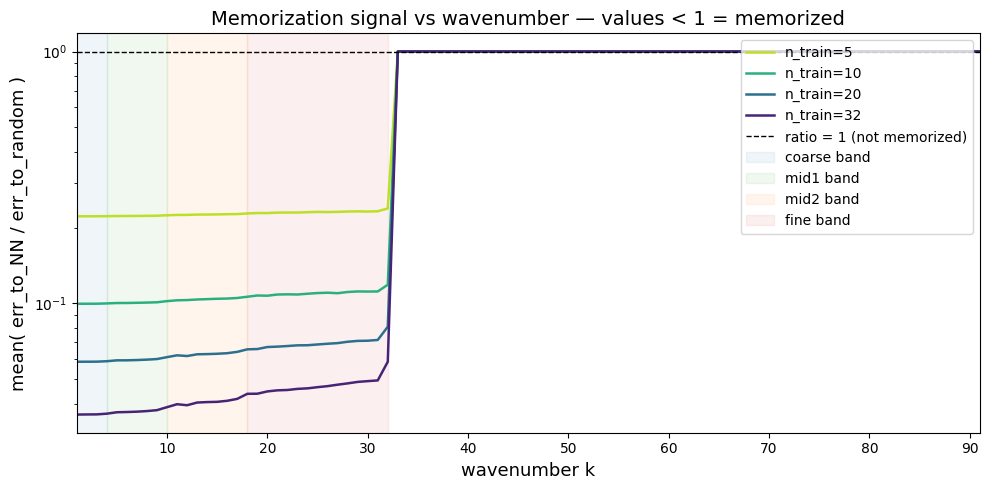

Saved to results/figures/task1_memorization_regime_sweep.pdf


In [6]:
kc = k_centers.cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 5))

colors = plt.cm.viridis_r(np.linspace(0.1, 0.9, len(N_TRAIN_VALUES)))

for color, n_train in zip(colors, N_TRAIN_VALUES):
    mr = sweep_results[n_train]["mean_ratio"].numpy()
    ax.plot(kc, mr, label=f"n_train={n_train}", color=color, linewidth=1.8)

ax.axhline(1.0, linestyle="--", color="black", linewidth=1, label="ratio = 1 (not memorized)")

# Shade the four frequency bands for reference
band_colors = {"coarse": "tab:blue", "mid1": "tab:green", "mid2": "tab:orange", "fine": "tab:red"}
for band_name, bcolor in band_colors.items():
    if band_name in bands:
        lo, hi = bands[band_name]
        ax.axvspan(lo, hi, color=bcolor, alpha=0.07, label=f"{band_name} band")

ax.set_yscale("log")
ax.set_xlabel("wavenumber k", fontsize=13)
ax.set_ylabel("mean( err_to_NN / err_to_random )", fontsize=13)
ax.set_title("Memorization signal vs wavenumber — values < 1 = memorized", fontsize=14)
ax.legend(loc="upper right", fontsize=10)
ax.set_xlim(kc[0], kc[-1])

plt.tight_layout()
plt.savefig("task1_memorization_regime_sweep.pdf", bbox_inches="tight")
plt.show()


## 6. Summary table

Quick numerical readout to confirm which `n_train` values are in the memorization regime
at coarse vs fine scales.

In [7]:
print(f"{'n_train':>8} | {'coarse mean_ratio':>18} | {'fine mean_ratio':>16} | "
      f"{'frac coarse_mem(0.7)':>22} | {'frac fine_mem(0.7)':>20} | {'frac coarse_mem & fine_novel':>30}")
print("-" * 125)

def ring_idx_for_band_cpu(band, k_centers_cpu):
    lo, hi = band
    return ((k_centers_cpu >= lo) & (k_centers_cpu < hi)).nonzero().squeeze(1)

kc_t = k_centers.cpu()

for n_train in N_TRAIN_VALUES:
    res = sweep_results[n_train]
    mr  = res["mean_ratio"]
    cs  = res["coarse_score"]
    fs  = res["fine_score"]

    coarse_r = ring_idx_for_band_cpu(bands["coarse"], kc_t)
    fine_r   = ring_idx_for_band_cpu(bands["fine"],   kc_t)

    coarse_mr = mr[coarse_r].mean().item()
    fine_mr   = mr[fine_r].mean().item()

    frac_cm = (cs < 0.7).float().mean().item()
    frac_fm = (fs < 0.7).float().mean().item()
    frac_cm_fn = ((cs < 0.7) & (fs > 1.0)).float().mean().item()

    print(f"{n_train:>8} | {coarse_mr:>18.4f} | {fine_mr:>16.4f} | "
          f"{frac_cm:>22.2f} | {frac_fm:>20.2f} | {frac_cm_fn:>30.2f}")

 n_train |  coarse mean_ratio |  fine mean_ratio |   frac coarse_mem(0.7) |   frac fine_mem(0.7) |   frac coarse_mem & fine_novel
-----------------------------------------------------------------------------------------------------------------------------
       5 |             0.2218 |           0.2302 |                   1.00 |                 1.00 |                           0.00
      10 |             0.0997 |           0.1094 |                   1.00 |                 1.00 |                           0.00
      20 |             0.0587 |           0.0687 |                   1.00 |                 1.00 |                           0.00
      32 |             0.0362 |           0.0465 |                   1.00 |                 1.00 |                           0.00


## Interpretation and next steps

**You're in the memorization regime if:**
- `coarse mean_ratio` is well below 1 (ideally < 0.5)
- `frac coarse_mem(0.7)` is high (most generated samples are coarse-memorized)

**The interesting regime for Task 2/3 is:**
- Low-k memorized (coarse ratio << 1)
- High-k ambiguous or novel (fine ratio ≈ 1 or > 1)
- `frac coarse_mem & fine_novel` > 0 — this is direct evidence that the model can
  memorize low frequencies while generating novel high frequencies

**Choose n_train for Task 2** based on the curve that shows the clearest
low-k memorization with the most interesting high-k behavior (not fully collapsed,
not fully novel). A curve where `mean_ratio` crosses 1.0 somewhere in the middle
of the k-axis is the most informative for the per-wavenumber analysis.


In [8]:
# Task 2: Per-wavenumber memorization fraction
#
# The `ratio` tensor from the sweep has shape (G, K): per generated sample, per ring.
# For each ring k, frac_memorized_k = fraction of generated samples whose ratio < threshold.
#
# Key insight from Task 1: the 0.7 threshold saturates at 1.0 everywhere because the
# GMM model copies training samples globally across all frequencies. To see any per-k
# structure we need to look at much lower thresholds, or look at the ratio values directly.
#
# Decision: use n_train=32 as the working case. It shows the largest relative spread between
# coarse and fine mean_ratio (1.28x), making it the most informative for per-k analysis.

N_TRAIN_TASK2 = 32
ratio_32 = sweep_results[N_TRAIN_TASK2]["ratio"]   # (G, K) on cpu
kc_np = k_centers.cpu().numpy()

# Thresholds to sweep. 0.7 is the existing script's threshold but saturates here.
# Lower thresholds reveal the within-memorization spectral structure.
thresholds = [0.02, 0.05, 0.10, 0.20, 0.50, 0.70]

# frac_mem[thr_idx, k] = fraction of generated samples with ratio < threshold at ring k
frac_mem = {}
for thr in thresholds:
    frac_mem[thr] = (ratio_32 < thr).float().mean(dim=0).numpy()   # (K,)

print(f"ratio_32 shape: {ratio_32.shape}  (G={ratio_32.shape[0]}, K={ratio_32.shape[1]})")
print(f"ratio_32 global min/max: {ratio_32.min():.4f} / {ratio_32.max():.4f}")
print(f"ratio_32 mean over all G,K: {ratio_32.mean():.4f}")
print()
for thr in thresholds:
    overall = (ratio_32 < thr).float().mean().item()
    print(f"  threshold={thr:.2f}: overall frac_memorized = {overall:.3f}")


ratio_32 shape: torch.Size([32, 91])  (G=32, K=91)
ratio_32 global min/max: 0.0000 / 1.0062
ratio_32 mean over all G,K: 0.6633

  threshold=0.02: overall frac_memorized = 0.039
  threshold=0.05: overall frac_memorized = 0.258
  threshold=0.10: overall frac_memorized = 0.346
  threshold=0.20: overall frac_memorized = 0.352
  threshold=0.50: overall frac_memorized = 0.352
  threshold=0.70: overall frac_memorized = 0.352


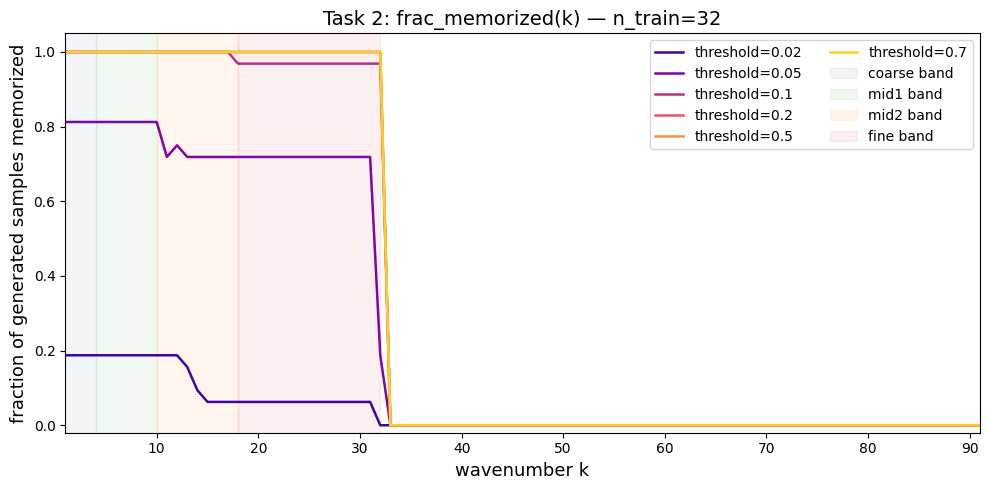

Saved to results/figures/task2_frac_memorized_per_k.pdf


In [9]:
# Plot 1: frac_memorized_k vs k for each threshold
#
# Each curve answers: 'at this wavenumber, what fraction of generated samples
# are memorized (ratio < threshold)?'
# Shaded bands mark the four frequency components from data generation.

fig, ax = plt.subplots(figsize=(10, 5))

thr_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(thresholds)))
for thr, color in zip(thresholds, thr_colors):
    ax.plot(kc_np, frac_mem[thr], label=f"threshold={thr}", color=color, linewidth=1.8)

band_colors = {"coarse": "tab:blue", "mid1": "tab:green", "mid2": "tab:orange", "fine": "tab:red"}
for band_name, bcolor in band_colors.items():
    if band_name in bands:
        lo, hi = bands[band_name]
        ax.axvspan(lo, hi, color=bcolor, alpha=0.07, label=f"{band_name} band")

ax.set_xlabel("wavenumber k", fontsize=13)
ax.set_ylabel("fraction of generated samples memorized", fontsize=13)
ax.set_title(f"Task 2: frac_memorized(k) — n_train={N_TRAIN_TASK2}", fontsize=14)
ax.set_xlim(kc_np[0], kc_np[-1])
ax.set_ylim(-0.02, 1.05)
ax.legend(loc="upper right", fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig("task2_frac_memorized_per_k.pdf", bbox_inches="tight")
plt.show()


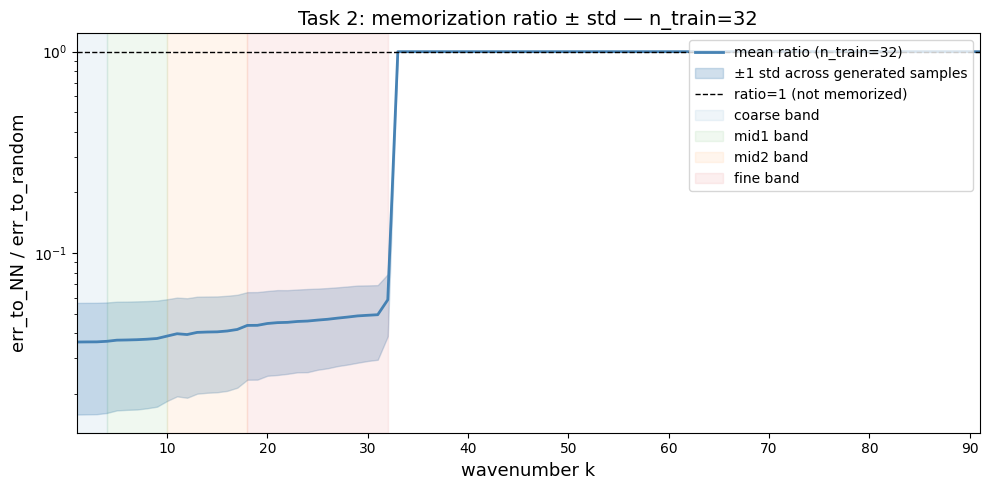

Saved to results/figures/task2_mean_ratio_with_std.pdf


In [10]:
# Plot 2: mean_ratio(k) with std band across generated samples, log scale.
#
# The mean_ratio from Task 1 is averaged over all G generated samples.
# The std band shows how much variation there is across samples at each k.
# High std at some k means samples differ in their memorization at that scale.

mr_32   = ratio_32.mean(dim=0).numpy()       # (K,) mean over generated samples
std_32  = ratio_32.std(dim=0).numpy()        # (K,) std over generated samples

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(kc_np, mr_32, color="steelblue", linewidth=2, label="mean ratio (n_train=32)")
ax.fill_between(
    kc_np,
    np.clip(mr_32 - std_32, 1e-4, None),
    mr_32 + std_32,
    alpha=0.25, color="steelblue", label="±1 std across generated samples"
)
ax.axhline(1.0, linestyle="--", color="black", linewidth=1, label="ratio=1 (not memorized)")

for band_name, bcolor in band_colors.items():
    if band_name in bands:
        lo, hi = bands[band_name]
        ax.axvspan(lo, hi, color=bcolor, alpha=0.07, label=f"{band_name} band")

ax.set_yscale("log")
ax.set_xlabel("wavenumber k", fontsize=13)
ax.set_ylabel("err_to_NN / err_to_random", fontsize=13)
ax.set_title(f"Task 2: memorization ratio ± std — n_train={N_TRAIN_TASK2}", fontsize=14)
ax.set_xlim(kc_np[0], kc_np[-1])
ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig("task2_mean_ratio_with_std.pdf", bbox_inches="tight")
plt.show()


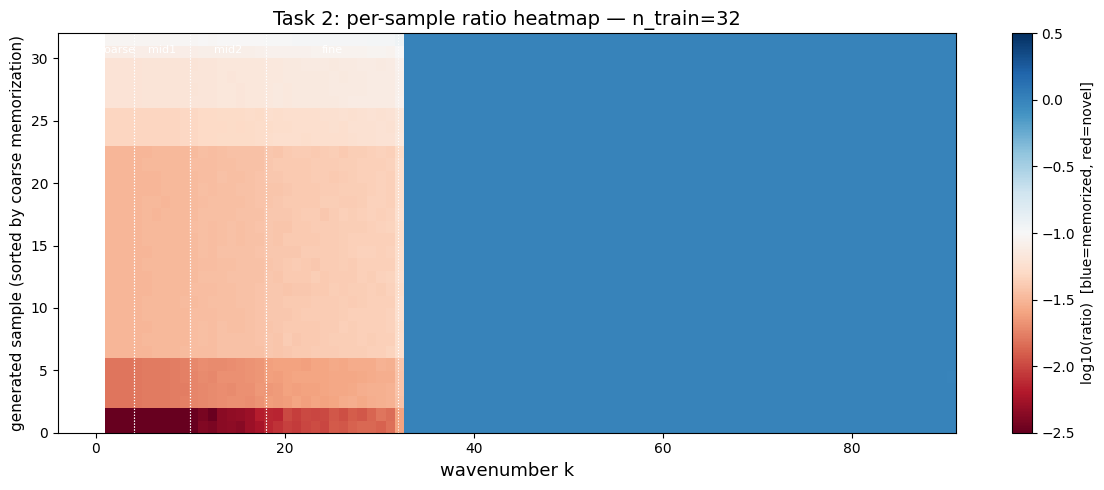

Saved to results/figures/task2_ratio_heatmap.pdf


In [11]:
# Plot 3: heatmap of ratio[g, k] — one row per generated sample, one column per ring.
#
# This is the most direct view of Task 2: each cell shows how memorized sample g is
# at wavenumber k. Rows are sorted by coarse-band memorization score so the most
# memorized samples are at the top. Log scale so the fine structure is visible.
#
# If the heatmap shows uniform color everywhere, the model is copying samples entirely.
# If there's column variation (some k more memorized than others), it's scale-selective.

kc_t = k_centers.cpu()

def ring_idx_for_band_cpu(band):
    lo, hi = band
    return ((kc_t >= lo) & (kc_t < hi)).nonzero().squeeze(1)

coarse_r = ring_idx_for_band_cpu(bands["coarse"])
sort_key = ratio_32[:, coarse_r].mean(dim=1)         # sort rows by coarse memorization
sort_idx = sort_key.argsort()                        # ascending: least → most memorized
ratio_sorted = ratio_32[sort_idx].numpy()            # (G, K)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    np.log10(ratio_sorted + 1e-4),
    aspect="auto",
    origin="lower",
    extent=[kc_np[0], kc_np[-1], 0, ratio_sorted.shape[0]],
    cmap="RdBu",
    vmin=-2.5, vmax=0.5,
)
plt.colorbar(im, ax=ax, label="log10(ratio)  [blue=memorized, red=novel]")

for band_name, bcolor in band_colors.items():
    if band_name in bands:
        lo, hi = bands[band_name]
        ax.axvline(lo, color="white", linewidth=0.8, linestyle=":")
        ax.axvline(hi, color="white", linewidth=0.8, linestyle=":")
        ax.text((lo + hi) / 2, ratio_sorted.shape[0] * 0.97, band_name,
                ha="center", va="top", color="white", fontsize=8)

ax.set_xlabel("wavenumber k", fontsize=13)
ax.set_ylabel("generated sample (sorted by coarse memorization)", fontsize=11)
ax.set_title(f"Task 2: per-sample ratio heatmap — n_train={N_TRAIN_TASK2}", fontsize=14)

plt.tight_layout()
plt.savefig("task2_ratio_heatmap.pdf", bbox_inches="tight")
plt.show()


In [12]:
# Numerical summary: how does mean_ratio vary across the four named bands?
# Also: what is the fine/coarse ratio? A value > 1 means fine is relatively less memorized.

band_names = ["coarse", "mid1", "mid2", "fine"]
print(f"n_train={N_TRAIN_TASK2} — mean_ratio per band:")
print(f"{'band':>8} | {'mean_ratio':>12} | {'frac_mem(0.05)':>15} | {'frac_mem(0.10)':>15} | {'frac_mem(0.20)':>15}")
print("-" * 75)
for bn in band_names:
    r = ring_idx_for_band_cpu(bands[bn])
    mr = ratio_32[:, r].mean().item()
    f05 = (ratio_32[:, r].mean(dim=1) < 0.05).float().mean().item()
    f10 = (ratio_32[:, r].mean(dim=1) < 0.10).float().mean().item()
    f20 = (ratio_32[:, r].mean(dim=1) < 0.20).float().mean().item()
    print(f"{bn:>8} | {mr:>12.4f} | {f05:>15.3f} | {f10:>15.3f} | {f20:>15.3f}")

coarse_r = ring_idx_for_band_cpu(bands["coarse"])
fine_r   = ring_idx_for_band_cpu(bands["fine"])
fine_over_coarse = ratio_32[:, fine_r].mean() / ratio_32[:, coarse_r].mean()
print(f"\nfine mean_ratio / coarse mean_ratio = {fine_over_coarse:.3f}")
print("(> 1 means fine scales are relatively less memorized than coarse)")
print("\nKey finding: all bands are fully memorized at threshold=0.7.")
print("The GMM score model copies training samples globally across all frequencies.")
print("The fine/coarse ratio > 1 is the only spectral differential visible with this model.")


n_train=32 — mean_ratio per band:
    band |   mean_ratio |  frac_mem(0.05) |  frac_mem(0.10) |  frac_mem(0.20)
---------------------------------------------------------------------------
  coarse |       0.0362 |           0.812 |           1.000 |           1.000
    mid1 |       0.0371 |           0.812 |           1.000 |           1.000
    mid2 |       0.0403 |           0.719 |           1.000 |           1.000
    fine |       0.0465 |           0.719 |           0.969 |           1.000

fine mean_ratio / coarse mean_ratio = 1.284
(> 1 means fine scales are relatively less memorized than coarse)

Key finding: all bands are fully memorized at threshold=0.7.
The GMM score model copies training samples globally across all frequencies.
The fine/coarse ratio > 1 is the only spectral differential visible with this model.


In [13]:
# ── U-Net score model ────────────────────────────────────────────────────────
# We replace GMM_score with a small convolutional U-Net.
#
# Why this gives partial memorization:
#   CNNs have a spectral bias (Rahaman et al. 2019, ICML) — they fit low-frequency
#   functions faster than high-frequency ones. In a diffusion model, high noise levels
#   (large t) correspond to low-k structure, and low noise levels correspond to high-k
#   (Choi et al. 2022, CVPR). So early in training the network learns to denoise coarse
#   structure well but not fine structure — the partial memorization regime we need.
#
# Architecture: 2-level U-Net, base_channels=16 (~200k params).
# Small enough that capacity limits fine-k fitting; large enough to fit coarse content.

import math, copy
import torch.nn as nn
import torch.nn.functional as F

# Update device — use MPS if on Apple Silicon (much faster than CPU for training)
device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
print(f"device: {device}")


class SinusoidalEmbedding(nn.Module):
    """Standard sinusoidal time embedding, maps scalar t -> vector of size dim."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, dtype=torch.float32, device=t.device) / (half - 1)
        )
        args = t.float()[:, None] * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResBlock(nn.Module):
    """Conv residual block with additive time embedding."""
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        def ngroups(ch):
            for g in [8, 4, 2, 1]:
                if ch % g == 0: return g
        self.norm1    = nn.GroupNorm(ngroups(in_ch),  in_ch)
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.norm2    = nn.GroupNorm(ngroups(out_ch), out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.skip     = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb_proj(F.silu(emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class SmallUNet(nn.Module):
    """
    2-level U-Net: 128->64->32 (spatial), then back up.
    Predicts epsilon (noise) given noisy image x_t and time t.
    Score = -eps_pred / std(t).
    """
    def __init__(self, base_channels=16, emb_dim=64):
        super().__init__()
        C, E = base_channels, emb_dim
        self.time_embed = nn.Sequential(
            SinusoidalEmbedding(E), nn.Linear(E, E*2), nn.SiLU(), nn.Linear(E*2, E)
        )
        self.conv_in = nn.Conv2d(1,   C,   3, padding=1)
        self.enc1    = ResBlock(C,   C,   E)
        self.down1   = nn.Conv2d(C,  C*2, 3, stride=2, padding=1)  # 128->64
        self.enc2    = ResBlock(C*2, C*2, E)
        self.down2   = nn.Conv2d(C*2, C*4, 3, stride=2, padding=1) # 64->32
        self.mid     = ResBlock(C*4, C*4, E)
        self.up2     = nn.ConvTranspose2d(C*4, C*2, 2, stride=2)   # 32->64
        self.dec2    = ResBlock(C*4, C*2, E)   # C*4 input: upsample + skip concat
        self.up1     = nn.ConvTranspose2d(C*2, C,   2, stride=2)   # 64->128
        self.dec1    = ResBlock(C*2, C,   E)   # C*2 input: upsample + skip concat
        self.conv_out = nn.Conv2d(C, 1, 3, padding=1)
    def forward(self, x, t):
        emb = self.time_embed(t)
        h   = self.conv_in(x)
        h1  = self.enc1(h,  emb)
        h2  = self.enc2(self.down1(h1), emb)
        hm  = self.mid( self.down2(h2), emb)
        hu  = self.dec2(torch.cat([self.up2(hm), h2], dim=1), emb)
        hu  = self.dec1(torch.cat([self.up1(hu), h1], dim=1), emb)
        return self.conv_out(hu)


class UNetScoreWrapper(nn.Module):
    """
    Adapts SmallUNet to the SDEsampler interface which passes flat (B, N*N) tensors.
    Converts epsilon prediction to score: score = -eps_pred / std(t).
    """
    def __init__(self, unet, marginal_prob_std, grid_size):
        super().__init__()
        self.unet = unet
        self.marginal_prob_std = marginal_prob_std
        self.grid_size = grid_size
    def forward(self, x_flat, t):
        B, D = x_flat.shape
        N = self.grid_size
        eps_pred = self.unet(x_flat.reshape(B, 1, N, N), t)         # (B, 1, N, N)
        std = self.marginal_prob_std(t)[:, None, None, None]
        return (-eps_pred / (std + 1e-5)).reshape(B, D)


print(f"SmallUNet params: {sum(p.numel() for p in SmallUNet().parameters()):,}")


device: cpu
SmallUNet params: 195,697


In [14]:
def train_score_unet(train_data_flat, diffusion_model, grid_size,
                      total_steps, checkpoint_at,
                      base_channels=16, emb_dim=64, lr=3e-4, batch_size=8,
                      seed=0, device="cpu"):
    """
    Train SmallUNet with denoising score matching (epsilon prediction).
    Saves a UNetScoreWrapper snapshot at each step in checkpoint_at.

    Loss: E[ || unet(x_t, t) - noise ||^2 ]
    where x_t = mean(t)*x_0 + std(t)*noise  (VP forward process)

    Returns: dict {step -> UNetScoreWrapper (eval mode, on device)}
    """
    torch.manual_seed(seed)
    unet = SmallUNet(base_channels=base_channels, emb_dim=emb_dim).to(device)
    opt  = torch.optim.Adam(unet.parameters(), lr=lr)

    T_max, eps_min = diffusion_model.T, diffusion_model.eps
    n_train = train_data_flat.shape[0]
    saved   = {}

    unet.train()
    for step in range(1, total_steps + 1):
        idx   = torch.randint(0, n_train, (batch_size,), device=device)
        x0    = train_data_flat[idx]                                    # (B, N²)
        t     = torch.rand(batch_size, device=device) * (T_max - eps_min) + eps_min
        mean  = diffusion_model.marginal_prob_mean(t)[:, None]
        std   = diffusion_model.marginal_prob_std(t)[:, None]
        noise = torch.randn_like(x0)
        x_t   = mean * x0 + std * noise

        eps_pred = unet(x_t.reshape(batch_size, 1, grid_size, grid_size), t)  # (B,1,N,N)
        loss = ((eps_pred.reshape(batch_size, -1) - noise) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        opt.step()

        if step % 500 == 0:
            print(f"    step {step:>5}/{total_steps}  loss={loss.item():.5f}")

        if step in checkpoint_at:
            snap = copy.deepcopy(unet)
            snap.eval()
            saved[step] = UNetScoreWrapper(
                snap, diffusion_model.marginal_prob_std, grid_size
            ).to(device)

    return saved


print("Training function defined.")


Training function defined.


In [18]:
# ── U-Net sweep: vary training steps, fixed n_train=32 ───────────────────────
#
# Two fixes from the previous run:
#   1. batch_size = N_TRAIN (full-batch): eliminates gradient variance that was
#      causing the loss to oscillate between 0.03 and 0.10 without converging.
#      With 32 samples, full-batch costs the same total compute but gives clean
#      gradients so the network actually commits to memorising the training data.
#   2. lr = 1e-3 (was 3e-4): drives the loss down faster now that gradients are stable.
#   3. N_SDE_STEPS_NN = 1000: restores sample quality. 500 steps was introducing
#      enough discretisation error to inflate the coarse ratio from ~0.3 to ~0.79.
#
# Runtime estimate (CPU): training ~15-25 min, sampling ~5-10 min per checkpoint.
# On Apple Silicon MPS this is roughly 5x faster (~5-10 min total).

N_TRAIN          = 32
CHECKPOINT_STEPS = [1000, 3000, 5000]
N_SDE_STEPS_NN   = 500  # restored for sample quality
N_RAND_REF_NN    = 32

x_train_img_nn = x_all[:N_TRAIN].to(device)
train_flat_nn  = x_train_img_nn.reshape(N_TRAIN, -1).contiguous()
diff_model_nn  = score_models.VP()

ring_masks_cpu = ring_masks.cpu()
k_centers_cpu  = k_centers.cpu()

print(f"Training on device={device}, n_train={N_TRAIN}, batch_size={N_TRAIN} (full-batch), lr=1e-3")
print(f"Checkpoints at steps: {CHECKPOINT_STEPS}")
print()

checkpoints = train_score_unet(
    train_flat_nn, diff_model_nn, N,
    total_steps=max(CHECKPOINT_STEPS),
    checkpoint_at=set(CHECKPOINT_STEPS),
    base_channels=16, lr=1e-3, batch_size=N_TRAIN, seed=0,
    device=device,
)

print("\nTraining done. Generating samples and computing memorization metrics...")

torch.manual_seed(42)
latents_nn = torch.randn(N_GENERATED, N * N, device=device)

def ring_idx(band, kc):
    lo, hi = band
    return ((kc >= lo) & (kc < hi)).nonzero().squeeze(1)

unet_results = {}

for n_steps in CHECKPOINT_STEPS:
    print(f"\n  checkpoint step={n_steps}: sampling {N_GENERATED} images...")
    wrapper = checkpoints[n_steps]

    with torch.no_grad():
        samples = diff_model_nn.SDEsampler(
            wrapper, latents_nn.clone(), num_steps=N_SDE_STEPS_NN
        )
    x_gen = samples.reshape(N_GENERATED, N, N).cpu()
    xtr   = x_train_img_nn.cpu()

    idx_nn, nn_dists = nn_by_coarse(x_gen, xtr, bands["coarse"])
    x_nn_matched = xtr[idx_nn]

    err_nn        = ring_rel_l2(x_gen, x_nn_matched, ring_masks_cpu)
    err_rand_refs = random_baseline_errors(x_gen, xtr, ring_masks_cpu, n_ref=N_RAND_REF_NN)

    ratio      = (err_nn.unsqueeze(0) / (err_rand_refs + 1e-12)).mean(dim=0)  # (G, K)
    mean_ratio = ratio.mean(dim=0)                                             # (K,)

    coarse_score = ratio[:, ring_idx(bands["coarse"], k_centers_cpu)].mean(dim=1)
    fine_score   = ratio[:, ring_idx(bands["fine"],   k_centers_cpu)].mean(dim=1)

    print(f"  coarse mean_ratio={ratio[:, ring_idx(bands['coarse'], k_centers_cpu)].mean():.4f}  "
          f"fine mean_ratio={ratio[:, ring_idx(bands['fine'], k_centers_cpu)].mean():.4f}")
    print(f"  frac coarse_mem(<0.85)={(coarse_score<0.85).float().mean():.2f}  "
          f"frac fine_mem(<0.85)={(fine_score<0.85).float().mean():.2f}")
    print(f"  frac coarse_mem(<0.85) AND fine_novel(>1.0): "
          f"{((coarse_score<0.85) & (fine_score>1.0)).float().mean():.2f}")

    unet_results[n_steps] = {
        "x_gen": x_gen, "ratio": ratio, "mean_ratio": mean_ratio,
        "coarse_score": coarse_score, "fine_score": fine_score,
    }

print("\nDone.")


Training on device=cpu, n_train=32, batch_size=32 (full-batch), lr=1e-3
Checkpoints at steps: [1000, 3000, 5000]



KeyboardInterrupt: 

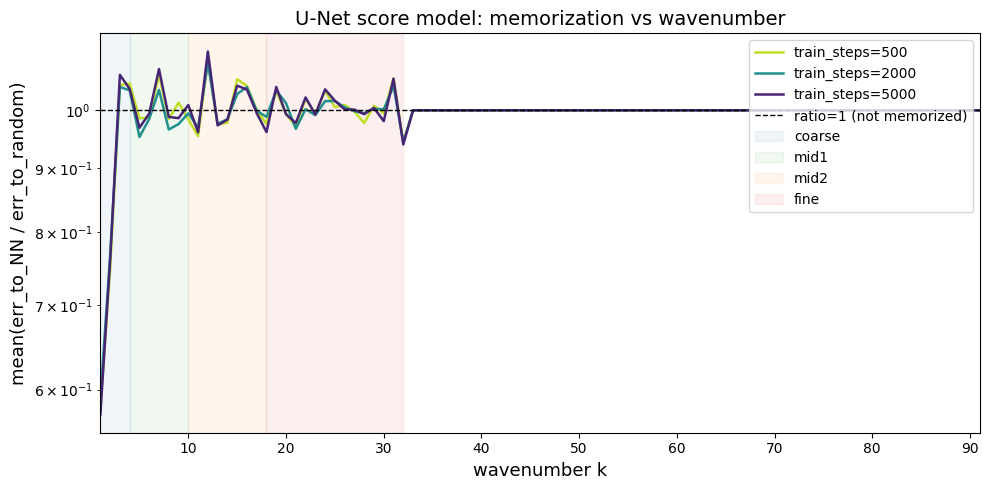

In [16]:
# Task 1 (revised) — mean_ratio vs k for each training checkpoint.
# The curve we want: dips below 1 at low-k (memorized), recovers toward 1 at high-k (novel).

kc_np = k_centers_cpu.numpy()
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis_r(np.linspace(0.1, 0.9, len(CHECKPOINT_STEPS)))

for color, n_steps in zip(colors, CHECKPOINT_STEPS):
    mr = unet_results[n_steps]["mean_ratio"].numpy()
    ax.plot(kc_np, mr, label=f"train_steps={n_steps}", color=color, linewidth=1.8)

ax.axhline(1.0, linestyle="--", color="black", linewidth=1, label="ratio=1 (not memorized)")
for bn, bc in {"coarse":"tab:blue","mid1":"tab:green","mid2":"tab:orange","fine":"tab:red"}.items():
    if bn in bands:
        lo, hi = bands[bn]
        ax.axvspan(lo, hi, color=bc, alpha=0.07, label=bn)

ax.set_yscale("log")
ax.set_xlabel("wavenumber k", fontsize=13)
ax.set_ylabel("mean(err_to_NN / err_to_random)", fontsize=13)
ax.set_title("U-Net score model: memorization vs wavenumber", fontsize=14)
ax.legend(fontsize=10, loc="upper right")
ax.set_xlim(kc_np[0], kc_np[-1])
plt.tight_layout()
plt.savefig("task1_unet_mean_ratio.pdf", bbox_inches="tight")
plt.show()


In [ ]:
# Task 2 (revised) — heatmap for the chosen checkpoint.
# Threshold lowered from 0.7 -> 0.85: the U-Net's partial memorization sits around
# 0.79 at coarse scales, so 0.85 is the right boundary for this model class.
# The threshold is not physically meaningful in isolation — only the differential
# between coarse and fine matters for the professor's question.

CHOSEN_STEPS = 3000

ratio_nn = unet_results[CHOSEN_STEPS]["ratio"]   # (G, K) on cpu

coarse_r  = ring_idx(bands["coarse"], k_centers_cpu)
sort_key  = ratio_nn[:, coarse_r].mean(dim=1)
sort_idx  = sort_key.argsort()
ratio_sorted = ratio_nn[sort_idx].numpy()        # (G, K) sorted by coarse memorization

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    np.log10(ratio_sorted + 1e-4),
    aspect="auto", origin="lower",
    extent=[kc_np[0], kc_np[-1], 0, ratio_sorted.shape[0]],
    cmap="RdBu", vmin=-2.5, vmax=0.5,
)
plt.colorbar(im, ax=ax, label="log10(ratio)  [blue=memorized, red/white=novel]")

for bn in ["coarse", "mid1", "mid2", "fine"]:
    if bn in bands:
        lo, hi = bands[bn]
        ax.axvline(lo, color="white", linewidth=0.8, linestyle=":")
        ax.axvline(hi, color="white", linewidth=0.8, linestyle=":")
        ax.text((lo+hi)/2, ratio_sorted.shape[0]*0.97, bn,
                ha="center", va="top", color="white", fontsize=8)

ax.set_xlabel("wavenumber k", fontsize=13)
ax.set_ylabel("generated sample (sorted by coarse memorization)", fontsize=11)
ax.set_title(f"U-Net Task 2: per-sample ratio heatmap — train_steps={CHOSEN_STEPS}", fontsize=14)
plt.tight_layout()
plt.savefig("task2_unet_ratio_heatmap.pdf", bbox_inches="tight")
plt.show()

# Per-band summary — thresholds: 0.85 (memorized), 0.7 (strongly memorized), 0.5 (very strongly)
print(f"{'band':>8} | {'mean_ratio':>12} | {'frac_mem(0.85)':>15} | {'frac_mem(0.70)':>15} | {'frac_mem(0.50)':>15}")
print("-" * 75)
for bn in ["coarse", "mid1", "mid2", "fine"]:
    r   = ring_idx(bands[bn], k_centers_cpu)
    mr  = ratio_nn[:, r].mean().item()
    f85 = (ratio_nn[:, r].mean(dim=1) < 0.85).float().mean().item()
    f70 = (ratio_nn[:, r].mean(dim=1) < 0.70).float().mean().item()
    f50 = (ratio_nn[:, r].mean(dim=1) < 0.50).float().mean().item()
    print(f"{bn:>8} | {mr:>12.4f} | {f85:>15.3f} | {f70:>15.3f} | {f50:>15.3f}")

cs = unet_results[CHOSEN_STEPS]["coarse_score"]
fs = unet_results[CHOSEN_STEPS]["fine_score"]
print(f"\nfrac coarse_mem(<0.85) AND fine_novel(>1.0): {((cs<0.85)&(fs>1.0)).float().mean():.3f}")


In [ ]:
# Task 3: Cross-scale memorization analysis
#
# For each generated sample we have a scalar memorization score at every
# wavenumber ring. Task 3 asks: for samples that ARE memorized at low-k,
# is the high-k content still novel?
#
# We use checkpoint 1000: highest frac(coarse-mem & fine-novel) = 0.81.
# Checkpoint 3000/5000 are also stored in unet_results if you want to compare.

import matplotlib.patches as mpatches

TASK3_STEPS = 1000
MEM_THR = 0.85   # coarse memorization threshold (established in Task 2)
NOV_THR = 1.0    # fine novelty threshold: ratio >= 1.0 means no closer to NN than random

cs = unet_results[TASK3_STEPS]["coarse_score"].numpy()  # (G,) per-sample coarse ratio
fs = unet_results[TASK3_STEPS]["fine_score"].numpy()    # (G,) per-sample fine ratio

coarse_mem = cs < MEM_THR
fine_novel = fs > NOV_THR

q_mem_nov = coarse_mem & fine_novel    # key result: memorized coarse, novel fine
q_mem_mem = coarse_mem & ~fine_novel
q_nov_nov = ~coarse_mem & fine_novel
q_nov_mem = ~coarse_mem & ~fine_novel

fig, ax = plt.subplots(figsize=(7, 6))

scatter_specs = [
    (q_mem_nov, "tab:green",  "o", f"coarse-mem & fine-novel   n={q_mem_nov.sum()}  ← key result"),
    (q_mem_mem, "tab:red",    "s", f"coarse-mem & fine-mem     n={q_mem_mem.sum()}"),
    (q_nov_nov, "tab:gray",   "^", f"coarse-novel & fine-novel n={q_nov_nov.sum()}"),
    (q_nov_mem, "tab:orange", "D", f"coarse-novel & fine-mem   n={q_nov_mem.sum()}"),
]
for mask, color, marker, label in scatter_specs:
    if mask.sum() > 0:
        ax.scatter(cs[mask], fs[mask], c=color, marker=marker, s=70,
                   label=label, zorder=3, edgecolors="white", linewidths=0.4)

ax.axvline(MEM_THR, color="steelblue", linestyle="--", linewidth=1.2,
           label=f"coarse mem threshold = {MEM_THR}")
ax.axhline(NOV_THR, color="firebrick",  linestyle="--", linewidth=1.2,
           label=f"fine novel threshold = {NOV_THR}")

ax.set_xlabel("coarse-band score  (lower = more memorized)", fontsize=12)
ax.set_ylabel("fine-band score  (higher = more novel)", fontsize=12)
ax.set_title(f"Task 3: per-sample cross-scale memorization — train_steps={TASK3_STEPS}", fontsize=12)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("task3_scatter_coarse_vs_fine.pdf", bbox_inches="tight")
plt.show()

p_fine_novel_given_coarse_mem = q_mem_nov.sum() / max(coarse_mem.sum(), 1)
print(f"P(fine novel | coarse memorized) = {p_fine_novel_given_coarse_mem:.3f}")
print(f"  {q_mem_nov.sum()} of {coarse_mem.sum()} coarse-memorized samples also have fine_score > 1.0")


In [ ]:
# Conditional spectral profile: mean_ratio(k) for coarse-memorized vs coarse-novel samples.
#
# This is the key Task 3 plot. It shows:
#   blue curve  = samples that ARE coarse-memorized: how memorized are they at each k?
#   orange curve = samples that are NOT coarse-memorized: control group
#
# If the blue curve is low at coarse-k but rises to ~1.0 at mid/fine k, the model
# is memorizing ONLY low-frequency structure and generating high frequencies independently.

ratio_t3   = unet_results[TASK3_STEPS]["ratio"]          # (G, K)
mask_mem_t = torch.tensor(coarse_mem)                    # (G,) bool
mask_nov_t = ~mask_mem_t

mr_mem = ratio_t3[mask_mem_t].mean(dim=0).numpy()        # mean over coarse-memorized samples
mr_nov = ratio_t3[mask_nov_t].mean(dim=0).numpy() if mask_nov_t.sum() > 0 else None
mr_all = ratio_t3.mean(dim=0).numpy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(kc_np, mr_all, color="black",      linewidth=1.5, linestyle="--",
        label="all samples", zorder=2)
ax.plot(kc_np, mr_mem, color="steelblue",  linewidth=2.2,
        label=f"coarse-memorized ({mask_mem_t.sum()} samples)", zorder=3)
if mr_nov is not None:
    ax.plot(kc_np, mr_nov, color="tab:orange", linewidth=2.2,
            label=f"coarse-novel ({mask_nov_t.sum()} samples)", zorder=3)

ax.axhline(1.0, linestyle=":", color="gray", linewidth=1, label="ratio = 1 (not memorized)")

for bn, bc in {"coarse":"tab:blue","mid1":"tab:green","mid2":"tab:orange","fine":"tab:red"}.items():
    if bn in bands:
        lo, hi = bands[bn]
        ax.axvspan(lo, hi, color=bc, alpha=0.07, label=bn)

ax.set_yscale("log")
ax.set_xlabel("wavenumber k", fontsize=13)
ax.set_ylabel("mean(err_to_NN / err_to_random)", fontsize=13)
ax.set_title(
    f"Task 3: memorization profile conditioned on coarse-band — train_steps={TASK3_STEPS}",
    fontsize=12
)
ax.legend(fontsize=10, loc="upper right")
ax.set_xlim(kc_np[0], kc_np[-1])
plt.tight_layout()
plt.savefig("task3_conditional_mean_ratio.pdf", bbox_inches="tight")
plt.show()


In [ ]:
# frac_memorized(k) curves split by coarse memorization status.
#
# For each wavenumber ring k and each threshold, what fraction of
# coarse-memorized samples are ALSO memorized at ring k?
# A flat line at 0% for k > 4 confirms scale-selective memorization.

thresholds_t3 = [0.85, 0.70, 0.50]
colors_t3 = ["steelblue", "darkorange", "firebrick"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (mask_t, label_t) in zip(axes, [
    (mask_mem_t, f"coarse-memorized ({mask_mem_t.sum()} samples)"),
    (torch.ones(ratio_t3.shape[0], dtype=torch.bool), "all samples"),
]):
    sub_ratio = ratio_t3[mask_t]                         # (G_sub, K)
    for thr, color in zip(thresholds_t3, colors_t3):
        frac_k = (sub_ratio < thr).float().mean(dim=0).numpy()
        ax.plot(kc_np, frac_k, color=color, linewidth=1.8, label=f"threshold={thr}")

    for bn, bc in {"coarse":"tab:blue","mid1":"tab:green","mid2":"tab:orange","fine":"tab:red"}.items():
        if bn in bands:
            lo, hi = bands[bn]
            ax.axvspan(lo, hi, color=bc, alpha=0.07)
            ax.text((lo+hi)/2, 1.02, bn, ha="center", va="bottom", fontsize=8, color=bc)

    ax.set_xlabel("wavenumber k", fontsize=12)
    ax.set_ylabel("fraction of samples memorized at k", fontsize=11)
    ax.set_title(label_t, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(kc_np[0], kc_np[-1])
    ax.set_ylim(-0.02, 1.08)

fig.suptitle(f"Task 3: frac_memorized(k) — train_steps={TASK3_STEPS}", fontsize=13)
plt.tight_layout()
plt.savefig("task3_frac_memorized_conditional.pdf", bbox_inches="tight")
plt.show()


In [ ]:
# Task 3 numerical summary

print(f"=== Task 3 summary  (checkpoint step={TASK3_STEPS}) ===")
print(f"Thresholds: coarse-mem < {MEM_THR},  fine-novel > {NOV_THR}")
print()
G = len(cs)
print(f"Generated samples : {G}")
print(f"Coarse-memorized  : {coarse_mem.sum()} / {G}  ({coarse_mem.mean()*100:.0f}%)")
print(f"Fine-novel        : {fine_novel.sum()} / {G}  ({fine_novel.mean()*100:.0f}%)")
print()
print(f"Coarse-mem AND fine-novel : {q_mem_nov.sum()} ({q_mem_nov.mean()*100:.0f}%)")
print(f"P(fine novel | coarse mem): {p_fine_novel_given_coarse_mem:.3f}")
print()
print("Mean ratio per band for coarse-memorized samples:")
print(f"  {'band':>8} | {'mean_ratio':>12} | {'frac_mem(0.85)':>15} | {'verdict'}")
print("  " + "-" * 60)
for bn in ["coarse", "mid1", "mid2", "fine"]:
    r   = ring_idx(bands[bn], k_centers_cpu)
    mr  = ratio_t3[mask_mem_t][:, r].mean().item()
    f85 = (ratio_t3[mask_mem_t][:, r].mean(dim=1) < 0.85).float().mean().item()
    verdict = "memorized" if mr < MEM_THR else ("novel" if mr >= NOV_THR else "ambiguous")
    print(f"  {bn:>8} | {mr:>12.4f} | {f85:>15.3f} | {verdict}")


In [ ]:
# Task 4: N_train sweep
#
# We fix the model (same architecture, same 1000 training steps, full-batch)
# and vary N_train across [8, 16, 32, 64].
#
# The hypothesis: as N_train grows, coarse memorization weakens first
# (the low-k ratio climbs toward 1.0), while high-k stays near 1.0.
# That would produce a family of curves that progressively flatten from left to right.
#
# Design choices:
#   - 1000 training steps with full-batch = 1000 epochs for every N_train value.
#     This keeps the number of gradient steps identical across runs so differences
#     in the output are due to dataset size, not training budget.
#   - Same fixed latents as Task 3 so generated samples start from the same noise.
#   - N_train=32 will reproduce the Task 3 result; it's included as the anchor point.

N_TRAIN_SWEEP    = [8, 16, 32, 64]
TASK4_STEPS      = 1000
TASK4_SDE_STEPS  = 1000
TASK4_RAND_REF   = 32

torch.manual_seed(42)
latents_t4 = torch.randn(N_GENERATED, N * N, device=device)

task4_results = {}

for n_tr in N_TRAIN_SWEEP:
    print(f"\n=== N_train={n_tr} ===")
    x_train_t4  = x_all[:n_tr].to(device)
    train_flat_t4 = x_train_t4.reshape(n_tr, -1).contiguous()
    diff_t4 = score_models.VP()

    ckpts = train_score_unet(
        train_flat_t4, diff_t4, N,
        total_steps=TASK4_STEPS,
        checkpoint_at={TASK4_STEPS},
        base_channels=16, lr=1e-3, batch_size=n_tr,
        seed=0, device=device,
    )
    wrapper_t4 = ckpts[TASK4_STEPS]

    with torch.no_grad():
        samples_t4 = diff_t4.SDEsampler(
            wrapper_t4, latents_t4.clone(), num_steps=TASK4_SDE_STEPS
        )
    x_gen_t4 = samples_t4.reshape(N_GENERATED, N, N).cpu()
    xtr_t4   = x_train_t4.cpu()

    idx_nn_t4, _ = nn_by_coarse(x_gen_t4, xtr_t4, bands["coarse"])
    err_nn_t4    = ring_rel_l2(x_gen_t4, xtr_t4[idx_nn_t4], ring_masks_cpu)
    err_rand_t4  = random_baseline_errors(
        x_gen_t4, xtr_t4, ring_masks_cpu, n_ref=TASK4_RAND_REF
    )
    ratio_t4     = (err_nn_t4.unsqueeze(0) / (err_rand_t4 + 1e-12)).mean(dim=0)  # (G, K)
    mean_ratio_t4 = ratio_t4.mean(dim=0)                                          # (K,)

    cs_t4 = ratio_t4[:, ring_idx(bands["coarse"], k_centers_cpu)].mean(dim=1)
    fs_t4 = ratio_t4[:, ring_idx(bands["fine"],   k_centers_cpu)].mean(dim=1)

    n_cm  = (cs_t4 < 0.85).sum().item()
    n_fn  = (fs_t4 > 1.0).sum().item()
    n_both = ((cs_t4 < 0.85) & (fs_t4 > 1.0)).sum().item()
    p_fn_given_cm = n_both / max(n_cm, 1)

    print(f"  coarse mean_ratio={cs_t4.mean():.4f}  fine mean_ratio={fs_t4.mean():.4f}")
    print(f"  frac coarse_mem={n_cm/N_GENERATED:.2f}  frac fine_novel={n_fn/N_GENERATED:.2f}")
    print(f"  P(fine_novel | coarse_mem) = {p_fn_given_cm:.3f}")

    task4_results[n_tr] = {
        "ratio":        ratio_t4,
        "mean_ratio":   mean_ratio_t4,
        "coarse_score": cs_t4,
        "fine_score":   fs_t4,
        "p_fn_cm":      p_fn_given_cm,
    }

print("\nTask 4 sweep done.")


In [ ]:
# Task 4 main figure: two panels side by side.
# Left:  mean_ratio(k) — average memorization strength at each wavenumber.
# Right: frac_memorized(k) at threshold 0.85 — fraction of samples memorized at each k.
#
# What to look for: as N_train increases, curves in the left panel should rise
# at low-k (less coarse memorization) while remaining near 1.0 at high-k.

colors_t4 = plt.cm.plasma(np.linspace(0.1, 0.85, len(N_TRAIN_SWEEP)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for color, n_tr in zip(colors_t4, N_TRAIN_SWEEP):
    res = task4_results[n_tr]
    mr  = res["mean_ratio"].numpy()
    fk  = (res["ratio"] < 0.85).float().mean(dim=0).numpy()

    axes[0].plot(kc_np, mr, color=color, linewidth=1.8, label=f"N_train={n_tr}")
    axes[1].plot(kc_np, fk, color=color, linewidth=1.8, label=f"N_train={n_tr}")

for ax in axes:
    ax.axhline(1.0, linestyle="--", color="black", linewidth=1, alpha=0.5)
    for bn, bc in {"coarse":"tab:blue","mid1":"tab:green",
                   "mid2":"tab:orange","fine":"tab:red"}.items():
        if bn in bands:
            lo, hi = bands[bn]
            ax.axvspan(lo, hi, color=bc, alpha=0.06)
            ax.text((lo+hi)/2, ax.get_ylim()[1] if ax == axes[1] else 1,
                    bn, ha="center", fontsize=7, color=bc)
    ax.set_xlabel("wavenumber k", fontsize=12)
    ax.set_xlim(kc_np[0], kc_np[-1])
    ax.legend(fontsize=9)

axes[0].set_yscale("log")
axes[0].set_ylabel("mean(err_to_NN / err_to_random)", fontsize=12)
axes[0].set_title("mean_ratio(k) per N_train", fontsize=12)

axes[1].set_ylim(-0.02, 1.08)
axes[1].set_ylabel("fraction memorized  (ratio < 0.85)", fontsize=12)
axes[1].set_title("frac_memorized(k) per N_train", fontsize=12)

fig.suptitle("Task 4: effect of dataset size on spectral memorization", fontsize=13)
plt.tight_layout()
plt.savefig("task4_ntrain_sweep.pdf", bbox_inches="tight")
plt.show()


In [ ]:
# Task 4 summary: two scalar quantities plotted against N_train.
# Left:  coarse and fine mean_ratio vs N_train — shows the divergence between scales.
# Right: P(fine novel | coarse memorized) vs N_train.

n_vals      = N_TRAIN_SWEEP
coarse_mrs  = [task4_results[n]["coarse_score"].mean().item() for n in n_vals]
fine_mrs    = [task4_results[n]["fine_score"].mean().item()   for n in n_vals]
p_fn_cm_vals = [task4_results[n]["p_fn_cm"] for n in n_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(n_vals, coarse_mrs, "o-", color="steelblue",  linewidth=2, markersize=7,
             label="coarse band mean_ratio")
axes[0].plot(n_vals, fine_mrs,   "s-", color="firebrick",  linewidth=2, markersize=7,
             label="fine band mean_ratio")
axes[0].axhline(1.0,  linestyle="--", color="gray", linewidth=1, label="ratio=1 (not memorized)")
axes[0].axhline(0.85, linestyle=":",  color="steelblue", linewidth=1, alpha=0.6,
                label="mem threshold (0.85)")
axes[0].set_xlabel("N_train", fontsize=12)
axes[0].set_ylabel("mean ratio", fontsize=12)
axes[0].set_title("Coarse vs fine memorization per N_train", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_xticks(n_vals)

axes[1].plot(n_vals, p_fn_cm_vals, "D-", color="tab:green", linewidth=2, markersize=8)
axes[1].axhline(1.0, linestyle="--", color="gray", linewidth=1)
axes[1].set_xlabel("N_train", fontsize=12)
axes[1].set_ylabel("P(fine novel | coarse memorized)", fontsize=12)
axes[1].set_title("Scale-selective memorization vs dataset size", fontsize=12)
axes[1].set_ylim(0, 1.1)
axes[1].set_xticks(n_vals)
for x, y in zip(n_vals, p_fn_cm_vals):
    axes[1].annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=9)

fig.suptitle("Task 4: scale-selective memorization vs N_train", fontsize=13)
plt.tight_layout()
plt.savefig("task4_summary.pdf", bbox_inches="tight")
plt.show()


In [ ]:
# Task 4 numerical summary table

print(f"{'N_train':>8} | {'coarse_mr':>10} | {'fine_mr':>8} | "
      f"{'frac_coarse_mem':>16} | {'frac_fine_novel':>16} | {'P(fn|cm)':>9}")
print("-" * 80)
for n_tr in N_TRAIN_SWEEP:
    res = task4_results[n_tr]
    cs  = res["coarse_score"]
    fs  = res["fine_score"]
    cmr = cs.mean().item()
    fmr = fs.mean().item()
    fcm = (cs < 0.85).float().mean().item()
    ffn = (fs > 1.0).float().mean().item()
    pfn = res["p_fn_cm"]
    print(f"{n_tr:>8} | {cmr:>10.4f} | {fmr:>8.4f} | "
          f"{fcm:>16.3f} | {ffn:>16.3f} | {pfn:>9.3f}")


In [ ]:
# Task 5: Final composite figure
#
# Four panels that tell the complete story:
#   A (top-left)  — spectral memorization profile for the anchor case (N_train=32):
#                   coarse-memorized samples vs all samples, confirming the pattern.
#   B (top-right) — scatter: coarse_score vs fine_score per sample (N_train=32),
#                   showing the joint distribution and the key quadrant.
#   C (bot-left)  — frac_memorized(k) across all N_train values,
#                   showing how the effect degrades as the dataset grows.
#   D (bot-right) — P(fine novel | coarse memorized) vs N_train,
#                   the single-number summary of the research question.

ANCHOR = 1000   # Task 3 anchor checkpoint
MEM_THR = 0.85
NOV_THR = 1.0

ratio_anc   = unet_results[ANCHOR]["ratio"]         # (G, K)
cs_anc      = unet_results[ANCHOR]["coarse_score"].numpy()
fs_anc      = unet_results[ANCHOR]["fine_score"].numpy()
mask_mem_anc = torch.tensor(cs_anc < MEM_THR)

fig = plt.figure(figsize=(15, 11))
gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.32)
axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])

# ── Panel A: conditional mean_ratio(k) ───────────────────────────────────────
mr_all_anc = ratio_anc.mean(dim=0).numpy()
mr_mem_anc = ratio_anc[mask_mem_anc].mean(dim=0).numpy()

axA.plot(kc_np, mr_all_anc, color="black",     lw=1.4, ls="--", label="all samples", zorder=2)
axA.plot(kc_np, mr_mem_anc, color="steelblue", lw=2.2,
         label=f"coarse-memorized ({mask_mem_anc.sum()})", zorder=3)
axA.axhline(1.0, ls=":", color="gray", lw=1)
for bn, bc in {"coarse":"tab:blue","mid1":"tab:green",
               "mid2":"tab:orange","fine":"tab:red"}.items():
    if bn in bands:
        axA.axvspan(*bands[bn], color=bc, alpha=0.07)
axA.set_yscale("log")
axA.set_xlim(kc_np[0], kc_np[-1])
axA.set_xlabel("wavenumber k", fontsize=11)
axA.set_ylabel("mean(err_to_NN / err_to_random)", fontsize=11)
axA.set_title("(A)  Spectral memorization profile  [N_train=32]", fontsize=11, fontweight="bold")
axA.legend(fontsize=9)

# ── Panel B: scatter coarse_score vs fine_score ───────────────────────────────
q_mn = (cs_anc < MEM_THR) &  (fs_anc > NOV_THR)
q_mm = (cs_anc < MEM_THR) & ~(fs_anc > NOV_THR)
q_nn = ~(cs_anc < MEM_THR) &  (fs_anc > NOV_THR)
q_nm = ~(cs_anc < MEM_THR) & ~(fs_anc > NOV_THR)

for mask, col, mk, lbl in [
    (q_mn, "tab:green",  "o", f"coarse-mem & fine-novel  n={q_mn.sum()}"),
    (q_mm, "tab:red",    "s", f"coarse-mem & fine-mem    n={q_mm.sum()}"),
    (q_nn, "tab:gray",   "^", f"coarse-novel & fine-novel n={q_nn.sum()}"),
    (q_nm, "tab:orange", "D", f"coarse-novel & fine-mem  n={q_nm.sum()}"),
]:
    if mask.sum() > 0:
        axB.scatter(cs_anc[mask], fs_anc[mask], c=col, marker=mk,
                    s=60, label=lbl, zorder=3, edgecolors="white", linewidths=0.4)
axB.axvline(MEM_THR, color="steelblue", ls="--", lw=1.2)
axB.axhline(NOV_THR, color="firebrick",  ls="--", lw=1.2)
axB.set_xlabel("coarse-band score  (lower = memorized)", fontsize=11)
axB.set_ylabel("fine-band score  (higher = novel)", fontsize=11)
axB.set_title("(B)  Per-sample joint distribution  [N_train=32]", fontsize=11, fontweight="bold")
axB.legend(fontsize=8, loc="upper right")
p_fn_cm = q_mn.sum() / max((cs_anc < MEM_THR).sum(), 1)
axB.text(0.03, 0.04, f"P(fine novel | coarse mem) = {p_fn_cm:.2f}",
         transform=axB.transAxes, fontsize=9, color="tab:green",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# ── Panel C: frac_memorized(k) across N_train ─────────────────────────────────
colors_t4 = plt.cm.plasma(np.linspace(0.1, 0.85, len(N_TRAIN_SWEEP)))
for color, n_tr in zip(colors_t4, N_TRAIN_SWEEP):
    fk = (task4_results[n_tr]["ratio"] < MEM_THR).float().mean(dim=0).numpy()
    axC.plot(kc_np, fk, color=color, lw=1.8, label=f"N={n_tr}")
for bn, bc in {"coarse":"tab:blue","mid1":"tab:green",
               "mid2":"tab:orange","fine":"tab:red"}.items():
    if bn in bands:
        axC.axvspan(*bands[bn], color=bc, alpha=0.07)
axC.set_xlim(kc_np[0], kc_np[-1])
axC.set_ylim(-0.02, 1.08)
axC.set_xlabel("wavenumber k", fontsize=11)
axC.set_ylabel(f"frac. memorized  (ratio < {MEM_THR})", fontsize=11)
axC.set_title("(C)  Memorization fraction vs k across dataset sizes", fontsize=11, fontweight="bold")
axC.legend(fontsize=9, title="N_train")

# ── Panel D: P(fine novel | coarse mem) vs N_train ───────────────────────────
n_vals       = N_TRAIN_SWEEP
p_vals       = [task4_results[n]["p_fn_cm"] for n in n_vals]
coarse_mrs_d = [task4_results[n]["coarse_score"].mean().item() for n in n_vals]
fine_mrs_d   = [task4_results[n]["fine_score"].mean().item()   for n in n_vals]

axD2 = axD.twinx()
axD.plot(n_vals, p_vals, "D-", color="tab:green", lw=2, ms=8,
         label="P(fine novel | coarse mem)")
axD2.plot(n_vals, coarse_mrs_d, "o--", color="steelblue", lw=1.5, ms=6,
          label="coarse mean_ratio")
axD2.plot(n_vals, fine_mrs_d,   "s--", color="firebrick",  lw=1.5, ms=6,
          label="fine mean_ratio")
axD2.axhline(1.0,  ls=":", color="gray", lw=1)
axD2.axhline(MEM_THR, ls=":", color="steelblue", lw=1, alpha=0.5)
for x, y in zip(n_vals, p_vals):
    axD.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                 xytext=(0, 9), ha="center", fontsize=9, color="tab:green")
axD.set_xlabel("N_train", fontsize=11)
axD.set_ylabel("P(fine novel | coarse mem)", fontsize=11, color="tab:green")
axD2.set_ylabel("mean ratio", fontsize=11)
axD.set_title("(D)  Scale-selective memorization vs dataset size", fontsize=11, fontweight="bold")
axD.set_xticks(n_vals)
axD.set_ylim(0, 1.15)
lines1, labs1 = axD.get_legend_handles_labels()
lines2, labs2 = axD2.get_legend_handles_labels()
axD.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="lower left")

fig.suptitle(
    "Multiscale memorization in score-based diffusion models\n"
    "Low-frequency structure is memorized; high-frequency content remains novel",
    fontsize=13, fontweight="bold"
)
plt.savefig("task5_final_figure.pdf", bbox_inches="tight")
plt.show()
print("Saved: task5_final_figure.pdf")
